In [1]:
#Imports
from pathlib import Path
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns, numpy as np

from pyspark.sql import functions as F

from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.sql.window import Window
from pyspark.ml.functions import vector_to_array

from project.config import load_config
from project.spark_session import create_spark
from project.schemas import TRANSACTION_SCHEMA
from project.transform import prepare_transactions
from project.fraud_modeling import split_by_label, undersample_training, oversample_training, hybrid_sample_training, fit_and_score_model, summarize_binary_predictions, build_comparison_df, show_summary, run_experiment

In [2]:
repo_root = Path.cwd().parent
cfg = load_config(repo_root / "configs" / "local.yaml")

raw_csv = repo_root / cfg.paths.raw

spark = create_spark(cfg)
spark.sparkContext.setLogLevel("WARN")

print("Spark session created.")
print(f"Raw data path: {raw_csv}")

Spark session created.
Raw data path: /home/jovyan/work/data/raw/credit_card_transactions.csv


In [3]:
print(f'Repo Root directory {repo_root}')

Repo Root directory /home/jovyan/work


In [3]:
df = (spark.read
         .option("header", True)
         .option("timestampFormat", "yyyy-MM-dd HH:mm:ss")
         .option("dateFormat", "yyyy-MM-dd")
         .schema(TRANSACTION_SCHEMA)
         .csv(str(raw_csv))
)

df = prepare_transactions(df)

In [4]:
numeric_features = [
    #"trans_date_trans_time", # Used derivated columns from this column
    #"cc_num", # Not used, too many cc#'s, noise
    "amt",
    #"zip", # Not used, generalized to state
    #"lat", # Not used
    #"long", # Not used
    "city_pop",
    #"dob", # Not used, derived "age" from this column for 
    #"trans_num", # Not used, noise
    #"unix_time", # Not used, better time metrics
    #"merch_lat", # Not used
    #"merch_long", # Not used
    #"zip", # Not used, generalized to state
    "event_hour", # Derived from 'trans_date_trans_time'
    "event_dayofweek", # Derived from 'trans_date_trans_time'
    "age",
]

categorical_features = [
    #"merchant", # Not used, too many vendors, noise
    "category",
    #"first", # Not used, noise
    #"last", # Not used, noise
    "gender",
    #"street", # Not used, noise
    #"city", # Not used, noise
    "state",
    #"job", # Not used, may implement
]

label_col = "is_fraud"

model_cols = numeric_features + categorical_features + [label_col]

model_df = df.select(*model_cols).dropna()

# Split Train Test

## Random Split

In [5]:
train_df, test_df = model_df.randomSplit([0.8, 0.2], seed=5420)

print(f"Train rows: {train_df.count():,}")
print(f"Test rows: {test_df.count():,}")

Train rows: 1,036,349
Test rows: 260,326


## Time Split

In [6]:
# Define window ordered by your timestamp column
window_spec = Window.orderBy("trans_date_trans_time")

# Add a percentile rank column (ranges from 0 to 1)
df_time = df.withColumn("rank", F.percent_rank().over(window_spec))

# Split at 80%
time_train_df = df_time.filter(F.col("rank") <= 0.8).drop("rank")
time_test_df = df_time.filter(F.col("rank") > 0.8).drop("rank")

print(f"Train rows: {time_train_df.count():,}")
print(f"Test rows: {time_test_df.count():,}")

print(time_train_df.tail(1))
time_test_df.head(1)

Train rows: 1,037,340
Test rows: 259,335
[Row(Unnamed: 0=1037339, trans_date_trans_time=datetime.datetime(2020, 3, 6, 7, 15, 17), cc_num='4822367783500458', merchant="fraud_Friesen-D'Amore", category='gas_transport', amt=93.02, first='Christopher', last='Farrell', gender='M', street='97070 Anderson Land', city='Haines City', state='FL', zip='33844', lat=28.0758, long=-81.5929, city_pop=33804, job='Exercise physiologist', dob=datetime.date(1991, 1, 1), trans_num='408a69cd781df5546489ecb28a2007ea', unix_time=1362554117, merch_lat=28.898967, merch_long=-81.74959100000001, is_fraud=0, merch_zipcode='32735', event_date=datetime.date(2020, 3, 6), event_hour=7, event_month=3, event_dayofweek=6, event_weekofyear=10, age=35, customer_name='Christopher Farrell', amt_log=4.5435075255959845)]


[Row(Unnamed: 0=1037340, trans_date_trans_time=datetime.datetime(2020, 3, 6, 7, 16, 43), cc_num='6544734391390261', merchant='fraud_Mosciski, Gislason and Mertz', category='grocery_pos', amt=45.16, first='John', last='Myers', gender='M', street='701 Wilson Divide', city='Highland', state='IN', zip='46322', lat=41.55, long=-87.4569, city_pop=23727, job='Community arts worker', dob=datetime.date(1982, 2, 8), trans_num='20fbf26eb491ec4173d969be75cf6184', unix_time=1362554203, merch_lat=40.90946, merch_long=-86.75995999999999, is_fraud=0, merch_zipcode='47959', event_date=datetime.date(2020, 3, 6), event_hour=7, event_month=3, event_dayofweek=6, event_weekofyear=10, age=44, customer_name='John Myers', amt_log=3.832113622199844)]

In [7]:
indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
    for c in categorical_features
]

encoders = [
    OneHotEncoder(inputCol=f"{c}_idx", outputCol=f"{c}_ohe")
    for c in categorical_features
]

assembler_inputs = numeric_features + [f"{c}_ohe" for c in categorical_features]

assembler = VectorAssembler(
    inputCols=assembler_inputs,
    outputCol="features"
)

In [8]:
lr = LogisticRegression(
    featuresCol="features",
    labelCol=label_col,
    predictionCol="prediction",
    probabilityCol="probability",
    rawPredictionCol="rawPrediction",
    maxIter=50,
    regParam=0.0,
    elasticNetParam=0.0
)

lr_pipeline = Pipeline(stages=indexers + encoders + [assembler, lr])

# Random Split
lr_model = lr_pipeline.fit(train_df)
lr_predictions = lr_model.transform(test_df)

# Time Split
time_lr_model = lr_pipeline.fit(time_train_df)
time_lr_predictions = lr_model.transform(time_test_df)

In [9]:
binary_eval = BinaryClassificationEvaluator(
    labelCol=label_col,
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

f1_eval = MulticlassClassificationEvaluator(
    labelCol=label_col,
    predictionCol="prediction",
    metricName="f1"
)

precision_eval = MulticlassClassificationEvaluator(
    labelCol=label_col,
    predictionCol="prediction",
    metricName="weightedPrecision"
)

recall_eval = MulticlassClassificationEvaluator(
    labelCol=label_col,
    predictionCol="prediction",
    metricName="weightedRecall"
)

In [10]:
lr_auc = binary_eval.evaluate(lr_predictions)
lr_f1 = f1_eval.evaluate(lr_predictions)
lr_precision = precision_eval.evaluate(lr_predictions)
lr_recall = recall_eval.evaluate(lr_predictions)

print("Logistic Regression Metrics")
print(f"AUC:       {lr_auc:.4f}")
print(f"F1:        {lr_f1:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")

Logistic Regression Metrics
AUC:       0.8198
F1:        0.9911
Precision: 0.9892
Recall:    0.9937


In [11]:
lr_predictions.groupBy("is_fraud", "prediction").count().orderBy("is_fraud", "prediction").show()

+--------+----------+------+
|is_fraud|prediction| count|
+--------+----------+------+
|       0|       0.0|258676|
|       0|       1.0|   115|
|       1|       0.0|  1515|
|       1|       1.0|    20|
+--------+----------+------+



In [12]:
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol=label_col,
    predictionCol="prediction",
    probabilityCol="probability",
    rawPredictionCol="rawPrediction",
    numTrees=100,
    maxDepth=10,
    seed=5420
)

rf_pipeline = Pipeline(stages=indexers + encoders + [assembler, rf])

In [13]:
# Random Split
rf_model = rf_pipeline.fit(train_df)
rf_predictions = rf_model.transform(test_df)

# Time Split
time_rf_model = rf_pipeline.fit(time_train_df)
time_rf_predictions = rf_model.transform(time_test_df)

In [14]:
rf_auc = binary_eval.evaluate(rf_predictions)
rf_f1 = f1_eval.evaluate(rf_predictions)
rf_precision = precision_eval.evaluate(rf_predictions)
rf_recall = recall_eval.evaluate(rf_predictions)

print("Random Forest Metrics")
print(f"AUC:       {rf_auc:.4f}")
print(f"F1:        {rf_f1:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")

Random Forest Metrics
AUC:       0.9810
F1:        0.9939
Precision: 0.9954
Recall:    0.9954


In [15]:
rf_predictions.groupBy("is_fraud", "prediction").count().orderBy("is_fraud", "prediction").show()

+--------+----------+------+
|is_fraud|prediction| count|
+--------+----------+------+
|       0|       0.0|258790|
|       0|       1.0|     1|
|       1|       0.0|  1196|
|       1|       1.0|   339|
+--------+----------+------+



In [16]:
comparison_rows = [
    ("Logistic Regression", round(lr_auc, 6), round(lr_f1, 6), round(lr_precision, 6), round(lr_recall, 6)),
    ("Random Forest", round(rf_auc, 6), round(rf_f1, 6), round(rf_precision, 6), round(rf_recall, 6)),
]

comparison_df = spark.createDataFrame(
    comparison_rows,
    ["model", "auc", "f1", "precision", "recall"]
)

comparison_df.show()

+-------------------+--------+--------+---------+--------+
|              model|     auc|      f1|precision|  recall|
+-------------------+--------+--------+---------+--------+
|Logistic Regression|0.819778|0.991123| 0.989189|0.993739|
|      Random Forest|0.980981|0.993942|  0.99541|0.995402|
+-------------------+--------+--------+---------+--------+



In [17]:
window = Window.partitionBy()

In [18]:
lr_fraud_preds, lr_fraud_summary = run_experiment(
    lr_pipeline,
    train_df,
    test_df,
    model_name="Logistic Regression (Random Split)",
    label_col="is_fraud",
    pred_col="prediction"
)

time_lr_fraud_preds, time_lr_fraud_summary = run_experiment(
    lr_pipeline,
    time_train_df,
    time_test_df,
    model_name="Logistic Regression (Time Split)",
    label_col="is_fraud",
    pred_col="prediction"
)

rf_fraud_preds, rf_fraud_summary = run_experiment(
    rf_pipeline,
    train_df,
    test_df,
    model_name="Random Forest (Random Split)",
    label_col="is_fraud",
    pred_col="prediction"
)

time_rf_fraud_preds, time_rf_fraud_summary = run_experiment(
    rf_pipeline,
    time_train_df,
    time_test_df,
    model_name="Random Forest (Time Split)",
    label_col="is_fraud",
    pred_col="prediction"
)

In [19]:
rand_time_compare_df = build_comparison_df(
    spark,[lr_fraud_summary, time_lr_fraud_summary, rf_fraud_summary, time_rf_fraud_summary]
)

rand_time_compare_df.show(truncate=False)

+----------------------------------+------+---+----+---+---------------+------------+--------+---------------+
|model                             |tn    |fp |fn  |tp |fraud_precision|fraud_recall|fraud_f1|nonfraud_recall|
+----------------------------------+------+---+----+---+---------------+------------+--------+---------------+
|Logistic Regression (Random Split)|258676|115|1515|20 |0.1481         |0.013       |0.024   |0.9996         |
|Logistic Regression (Time Split)  |257692|105|1522|16 |0.1322         |0.0104      |0.0193  |0.9996         |
|Random Forest (Random Split)      |258790|1  |1196|339|0.9971         |0.2208      |0.3616  |1.0            |
|Random Forest (Time Split)        |257784|13 |1096|442|0.9714         |0.2874      |0.4436  |0.9999         |
+----------------------------------+------+---+----+---+---------------+------------+--------+---------------+



In [30]:
visual_df = pd.read_csv(raw_csv)

visual_df["trans_date_trans_time"] = pd.to_datetime(
    visual_df["trans_date_trans_time"],
    format="%Y-%m-%d %H:%M:%S"
)

visual_df["hour"] = visual_df["trans_date_trans_time"].dt.hour
visual_df["day"] = visual_df["trans_date_trans_time"].dt.day
visual_df["month"] = visual_df["trans_date_trans_time"].dt.month
visual_df["weekday"] = visual_df["trans_date_trans_time"].dt.day_name()

# Binary flags
visual_df["is_night"] = np.where(
    visual_df["hour"].between(0, 5), 1, 0
)

visual_df["is_weekend"] = np.where(
    visual_df["day"].isin([1, 7]), 1, 0
)

# Log transform
visual_df["amt_log"] = np.log1p(visual_df["amt"])

# High amount flag
visual_df["high_amt_flag"] = np.where(
    visual_df["amt"] > 200, 1, 0
)

# Geographic differences
visual_df["lat_diff"] = np.abs(
    visual_df["lat"] - visual_df["merch_lat"]
)

visual_df["long_diff"] = np.abs(
    visual_df["long"] - visual_df["merch_long"]
)

# Distance proxy
visual_df["distance_proxy"] = np.sqrt(
    visual_df["lat_diff"]**2 + visual_df["long_diff"]**2
)

# Group-based features (window equivalent)
visual_df["avg_amt_per_card"] = (
    visual_df.groupby("cc_num")["amt"]
    .transform("mean")
)

visual_df["amt_vs_avg"] = (
    visual_df["amt"] / visual_df["avg_amt_per_card"]
)

In [31]:
visual_df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud', 'merch_zipcode', 'hour', 'day',
       'month', 'weekday', 'is_night', 'is_weekend', 'amt_log',
       'high_amt_flag', 'lat_diff', 'long_diff', 'distance_proxy',
       'avg_amt_per_card', 'amt_vs_avg'],
      dtype='object')

In [32]:
visual_df.shape

(1296675, 37)

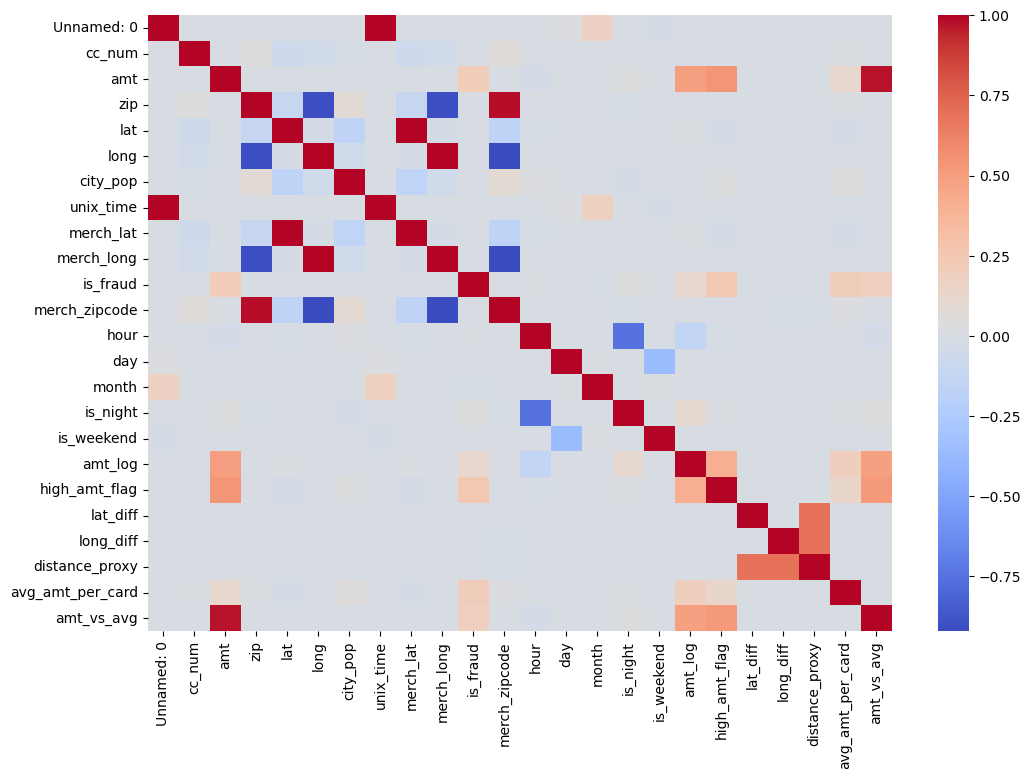

In [34]:
numeric_df = visual_df.select_dtypes(include=["number"])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm")
plt.show()

In [38]:
fraud_corr = (
    visual_df
    .corr(numeric_only=True)["is_fraud"]
    .drop("is_fraud")
    .sort_values(ascending=False)
)

print(fraud_corr)

high_amt_flag       0.254827
amt                 0.219404
avg_amt_per_card    0.209960
amt_vs_avg          0.196145
amt_log             0.120439
is_night            0.029622
hour                0.013799
day                 0.003848
city_pop            0.002136
lat                 0.001894
merch_lat           0.001741
merch_long          0.001721
long                0.001721
lat_diff            0.000655
distance_proxy      0.000434
long_diff          -0.000201
cc_num             -0.000981
zip                -0.002162
merch_zipcode      -0.002992
is_weekend         -0.003086
Unnamed: 0         -0.004767
unix_time          -0.005078
month              -0.012409
Name: is_fraud, dtype: float64


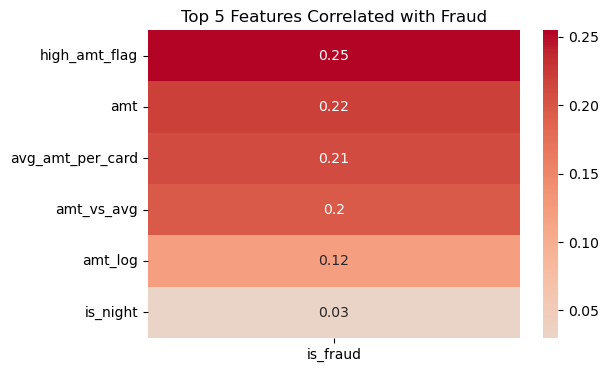

In [51]:
top5 = fraud_corr.head(6)

plt.figure(figsize=(6, 4))
sns.heatmap(
    top5.to_frame(),
    annot=True,
    cmap="coolwarm",
    center=0
)
plt.title("Top 5 Features Correlated with Fraud")
plt.show()